# Counts, density, and variable-width bins

Khisto chooses adaptive bins, so their widths can differ. That makes one
distinction essential: **counts describe how many observations fall in a bin;
density describes how concentrated those observations are over the bin's
width**.

By the end of this guide, you will know what bar height and bar area mean in
each view, and which view to choose for your question.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from khisto import histogram

SEED = 42
rng = np.random.default_rng(SEED)
data = np.concatenate([
    rng.normal(0, 0.35, 6000),
    rng.normal(2.5, 1.0, 3000),
    rng.exponential(2.0, 1000) + 4,
])

counts, bin_edges = histogram(data, density=False)
density, density_edges = histogram(data, density=True)

np.testing.assert_array_equal(bin_edges, density_edges)
widths = np.diff(bin_edges)
probabilities = counts / counts.sum()

assert counts.sum() == data.size
assert np.isclose(np.sum(density * widths), 1.0)

print(f"Observations: {int(counts.sum()):,}")
print(f"Adaptive bins: {len(counts)}")
print(f"Sum of density areas: {np.sum(density * widths):.6f}")

Observations: 10,000
Adaptive bins: 23
Sum of density areas: 1.000000


## One histogram, two questions

For bin $i$, let:

- $c_i$ be its count,
- $w_i$ be its width,
- $N$ be the total number of observations.

The relative frequency is $p_i = c_i / N$. The density is

$$d_i = \frac{c_i}{N w_i} = \frac{p_i}{w_i}.$$

A count bar's **height** answers "how many observations?" A density bar's
**area** answers "what fraction of observations?" because

$$d_i w_i = p_i,$$

and all density-bar areas sum to 1. Dividing by width is what makes bins of
different widths comparable.

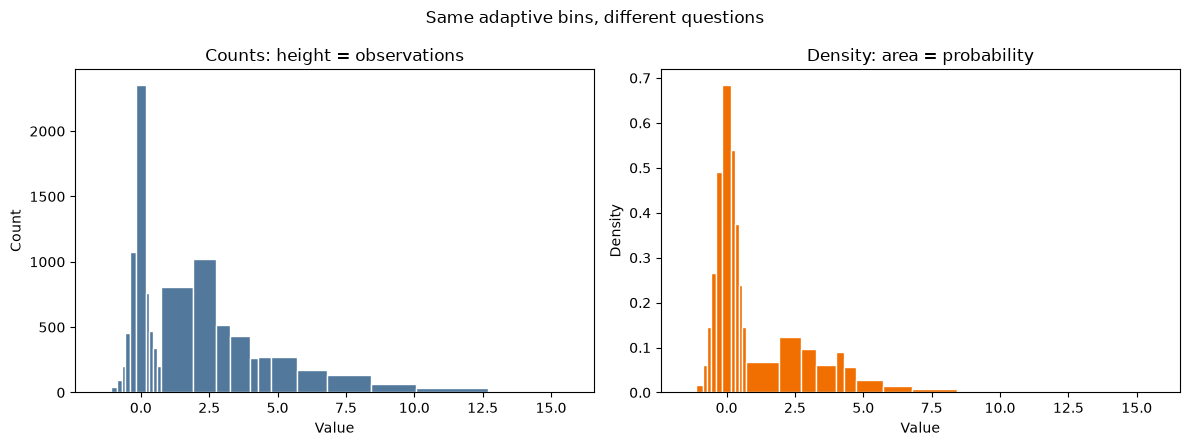

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    bin_edges[:-1], counts, width=widths, align="edge",
    color="#52789c", edgecolor="white",
)
axes[0].set_title("Counts: height = observations")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

axes[1].bar(
    bin_edges[:-1], density, width=widths, align="edge",
    color="#f16e00", edgecolor="white",
)
axes[1].set_title("Density: area = probability")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")

fig.suptitle("Same adaptive bins, different questions")
plt.tight_layout()
plt.show()

With unequal widths, raw count heights are not directly comparable: a wide bin
has more room to collect observations. Density corrects for that extra width.

Use **counts** when totals matter, such as workload or sample size. Use
**density** when reading distribution shape or comparing samples of different
sizes.

## The key example: equal counts, unequal widths

Imagine two bins that each contain 50 of 100 observations. Their widths are 1
and 4. Both count heights are 50, but their densities are 0.5 and 0.125. Values
are therefore **four times more concentrated** in the narrow bin.

In the density view, the bars have different heights but equal areas:

- narrow bin: $0.5 \times 1 = 0.5$,
- wide bin: $0.125 \times 4 = 0.5$.

Each area correctly shows that the bin contains half of the observations.

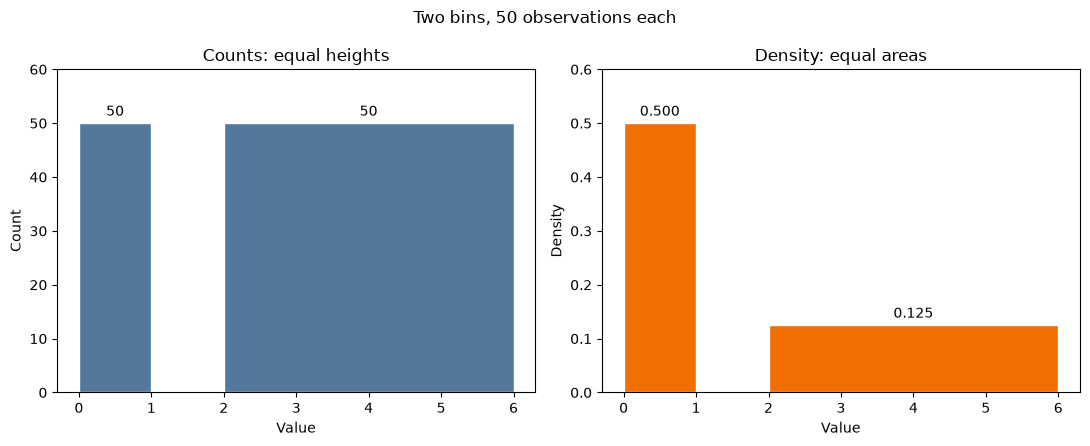

In [3]:
example_left_edges = np.array([0.0, 2.0])
example_widths = np.array([1.0, 4.0])
example_counts = np.array([50, 50])
example_density = example_counts / (example_counts.sum() * example_widths)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)

count_bars = axes[0].bar(
    example_left_edges, example_counts, width=example_widths, align="edge",
    color="#52789c", edgecolor="white",
)
axes[0].bar_label(count_bars, labels=["50", "50"], padding=3)
axes[0].set_title("Counts: equal heights")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 60)

density_bars = axes[1].bar(
    example_left_edges, example_density, width=example_widths, align="edge",
    color="#f16e00", edgecolor="white",
)
axes[1].bar_label(density_bars, labels=["0.500", "0.125"], padding=3)
axes[1].set_title("Density: equal areas")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")
axes[1].set_ylim(0, 0.6)

fig.suptitle("Two bins, 50 observations each")
plt.tight_layout()
plt.show()

## Reading variable-width histograms

| Question | Use | What to compare |
| --- | --- | --- |
| How many observations? | Counts (`density=False`) | Bar heights |
| What fraction of observations? | Counts divided by $N$, or density | Bar areas |
| Where are values concentrated? | Density (`density=True`, the Khisto default) | Bar heights |

Before interpreting a histogram:

1. Notice whether bin widths differ.
2. Identify whether the y-axis shows count or density.
3. For density, read each bar's **area** as probability.

## Go further

Continue with [Histograms - Khiops](https://khiops.org/learn/histograms/) for
the principles behind Khiops histograms, from the simplest to the most complex.